In [37]:
%%capture
%pip install -q --upgrade scikit-learn==1.4.2 imbalanced-learn==0.12.3

In [38]:
import sys, sklearn, imblearn
print("Python:", sys.version.split()[0])
print("scikit-learn:", sklearn.__version__, "| imbalanced-learn:", imblearn.__version__)


Python: 3.12.9
scikit-learn: 1.4.2 | imbalanced-learn: 0.12.3


# Pima Indians Diabetes Prediction

## Background

Diabetes is one of the fastest-growing global health problems. Early prediction can save lives and reduce complications.

Dataset: **[Pima Indians Diabetes]** (768 women, age ≥ 21).  
This dataset is widely used for teaching medical machine learning pipelines; it reflects routine clinical measurements rather than advanced tests.

**Note:** only ~35% of patients in this dataset are diabetic — handling class imbalance is critical.

**Goal:** build an end-to-end, production-friendly pipeline to predict diabetes from routine measurements.  
We cover **EDA → feature engineering → pipelines (no leakage) → model comparison → calibration + cost-based thresholding → interpretation → deployment artifacts**.


## Data Dictionary

| Feature                 | Description                                           |
|------------------------|-------------------------------------------------------|
| Pregnancies            | Number of times pregnant (count)                      |
| Glucose                | Plasma glucose concentration (mg/dL)                  |
| BloodPressure          | Diastolic blood pressure (mm Hg)                      |
| SkinThickness          | Triceps skinfold thickness (mm)                       |
| Insulin                | 2-Hour serum insulin (µU/mL)                          |
| BMI                    | Body mass index (kg/m²)                               |
| DiabetesPedigreeFunction | Diabetes pedigree function (genetic risk score)     |
| Age                    | Age (years)                                           |
| Outcome                | 1 = diabetes, 0 = non-diabetes                        |


# Import Libraries

In [39]:
import os, warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from IPython.display import display
import plotly.express as px
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve,
    average_precision_score, brier_score_loss, make_scorer
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.inspection import permutation_importance

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except Exception:
    HAS_XGB = False

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Global config
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
sns.set_context("notebook", font_scale=1.2)
plt.rcParams["figure.figsize"] = (8.5, 5)

# Cost settings 
COST_FP = 1.0
COST_FN = 7.0



# Load Dataset

In [ ]:
from pathlib import Path

local_path = Path('data/raw/diabetes.csv')
kaggle_path = Path('/kaggle/input/pima-indians-diabetes-database/diabetes.csv')

if local_path.exists():
    df = pd.read_csv(local_path)
else:
    df = pd.read_csv(kaggle_path)


# Initial Data Exploration

In [41]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [43]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [44]:
df.shape

(768, 9)

# Data Cleaning & Preprocessing (EDA)

## Check missing values & duplicates


In [45]:
# Missing values 
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [46]:
# Remove duplicates
df.duplicated().sum()

np.int64(0)

### No explicit nulls. Zeros in some columns represent missing data

## Replace Impossible Zeros with NaN

In [47]:
BASE_FEATURES = ['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age']

def zeros_to_nan(X: pd.DataFrame) -> pd.DataFrame:
    X = X.copy()
    cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
    X[cols] = X[cols].replace(0, np.nan)
    return X

def add_interactions(X: pd.DataFrame) -> pd.DataFrame:
    X = X.copy()
    X['Age_BMI']        = X['Age'] * X['BMI']
    X['Glucose_BMI']    = X['Glucose'] * X['BMI']
    X['Preg_Age_Ratio'] = X['Pregnancies'] / (X['Age'] + 1)
    return X

def expected_cost(y_true, proba, thr, cost_fp=COST_FP, cost_fn=COST_FN):
    yhat = (proba >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, yhat).ravel()
    return fp * cost_fp + fn * cost_fn


# Feature engineering (for EDA visuals)


In [48]:
df_vis = df.copy()
cols_with_zero = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
df_vis[cols_with_zero] = df_vis[cols_with_zero].replace(0, np.nan)
for c in cols_with_zero:
    df_vis[c].fillna(df_vis[c].median(), inplace=True)


## Age Groups

In [49]:
df_vis['AgeGroup'] = pd.cut(df_vis['Age'], bins=[20,30,40,50,60,100], labels=['20s','30s','40s','50s','60s+'])

## BMI Categories

In [50]:
df_vis['BMI_Category'] = pd.cut(df_vis['BMI'], bins=[0,18.5,25,30,100], labels=['Underweight','Normal','Overweight','Obese'])

## New features

In [51]:
df_vis['Age_BMI'] = df_vis['Age'] * df_vis['BMI']
df_vis['Glucose_BMI'] = df_vis['Glucose'] * df_vis['BMI']
df_vis['Preg_Age_Ratio'] = df_vis['Pregnancies'] / (df_vis['Age'] + 1)

### Creating compound features to capture complex risk interactions.



# Exploratory Data Analysis (EDA) & Visualization

## Class Imbalance Visualization

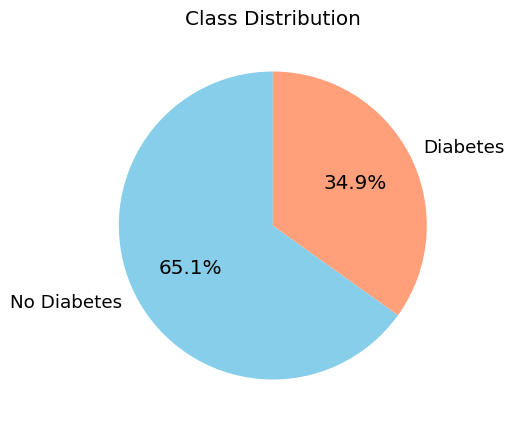

In [52]:
plt.figure(figsize=(5,5))
df['Outcome'].value_counts().plot.pie(
    labels=['No Diabetes','Diabetes'],
    autopct='%1.1f%%',
    colors=['#87CEEB','#FFA07A'],
    startangle=90
)
plt.title('Class Distribution')
plt.ylabel('')
plt.show()

### About 65% of cases are non-diabetic and 35% diabetic. Class imbalance may bias models toward majority class.


## Pairplot

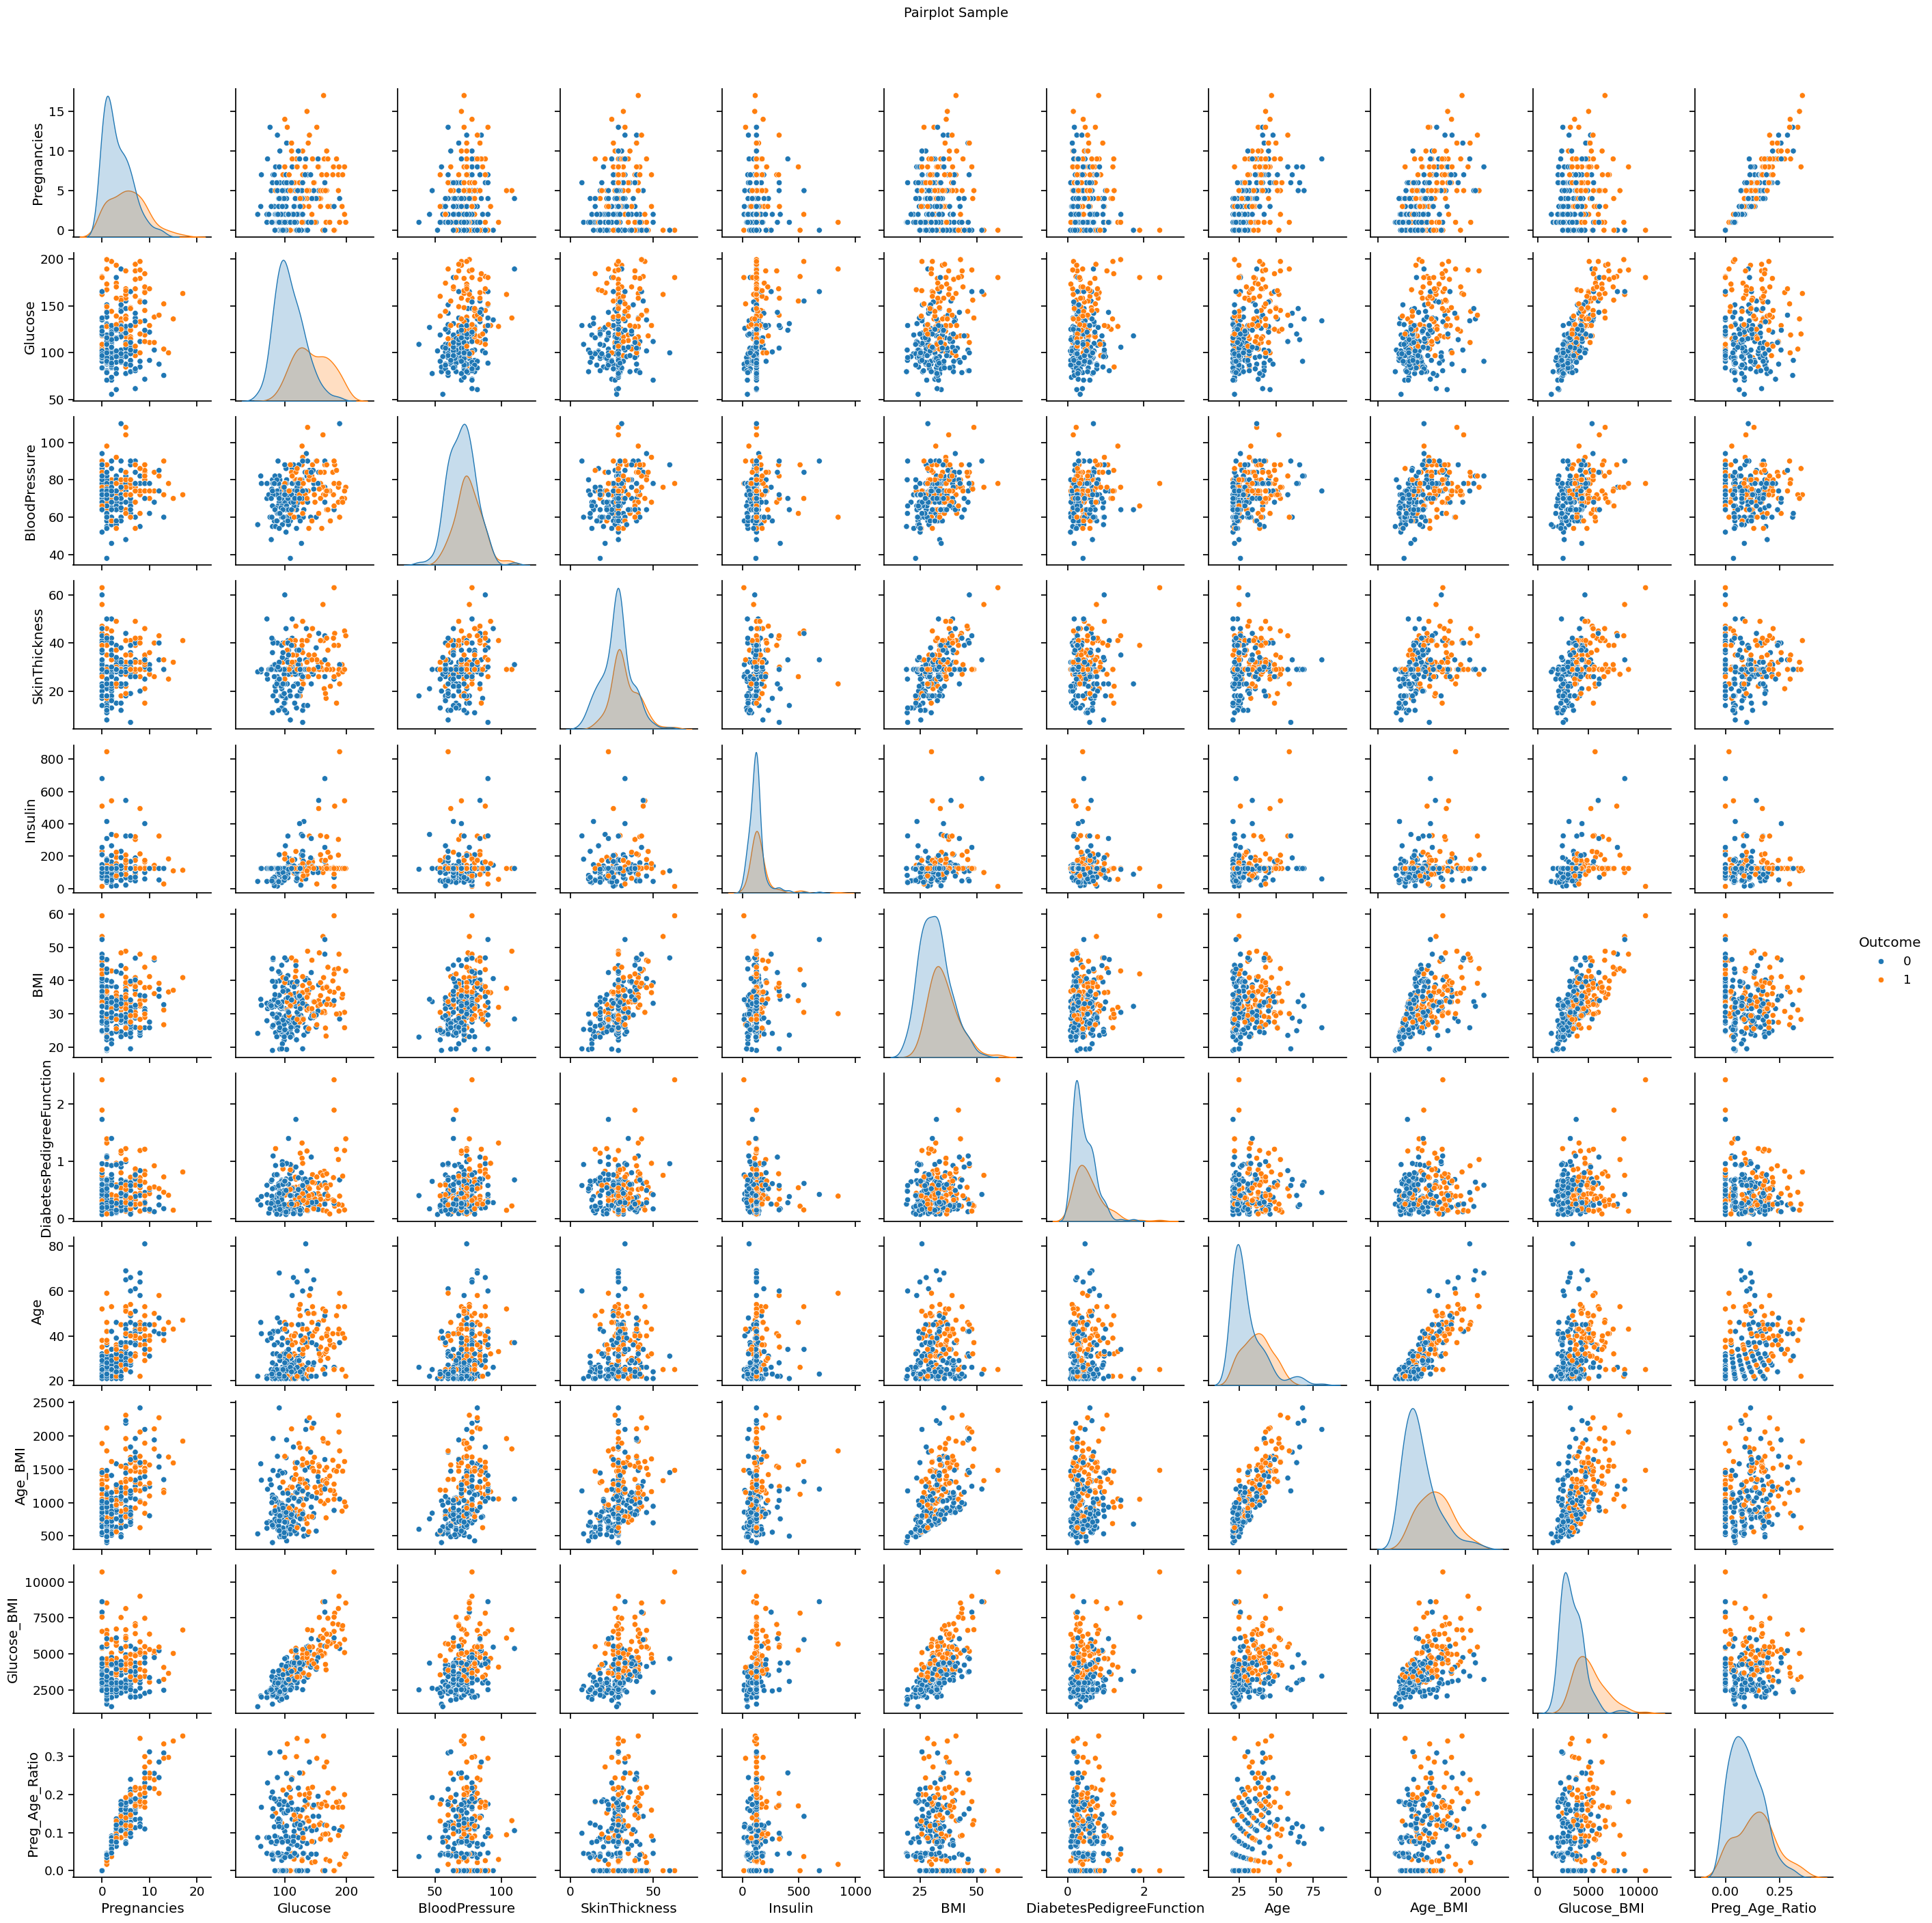

In [53]:
sns.pairplot(df_vis.sample(250, random_state=1), hue='Outcome', diag_kind='kde')
plt.suptitle("Pairplot Sample", fontsize=14, y= 1.03)
plt.show()

### Pairplot shows that most diabetic cases cluster at high Glucose and BMI values.


## Glucose vs BMI colored by Outcome

In [54]:
fig = px.scatter(
    df_vis, x="Glucose", y="BMI",
    color=df_vis["Outcome"].map({0:"No Diabetes",1:"Diabetes"}),
    hover_data=["Age","Pregnancies","BloodPressure","SkinThickness","Insulin"],
    title="Glucose vs BMI — Outcome"
)
fig.update_layout(legend_title_text="Outcome")
fig.show()


### The scatter shows a clear cluster: patients with both high glucose and high BMI


## Correlation matrix

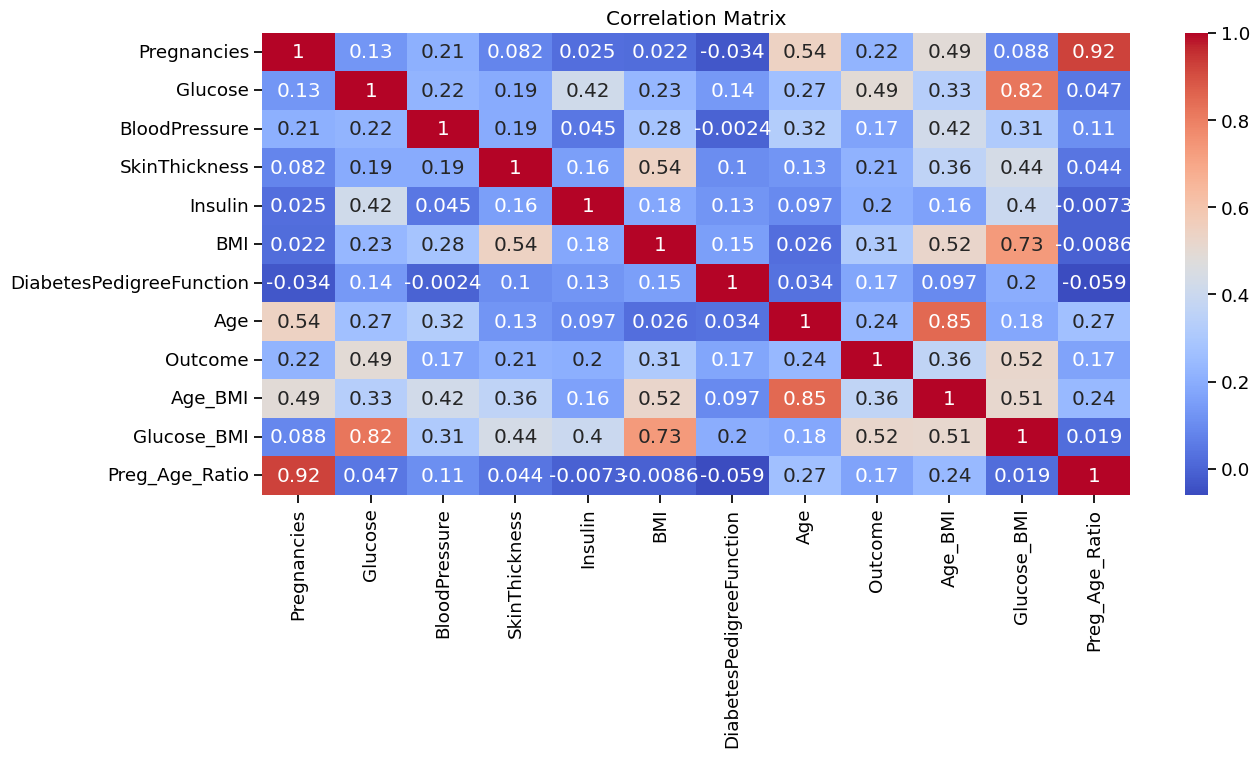

In [55]:
plt.figure(figsize=(14,6))
sns.heatmap(df_vis.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

### Glucose is most strongly correlated with diabetes outcome.


## Features Distribution by Class

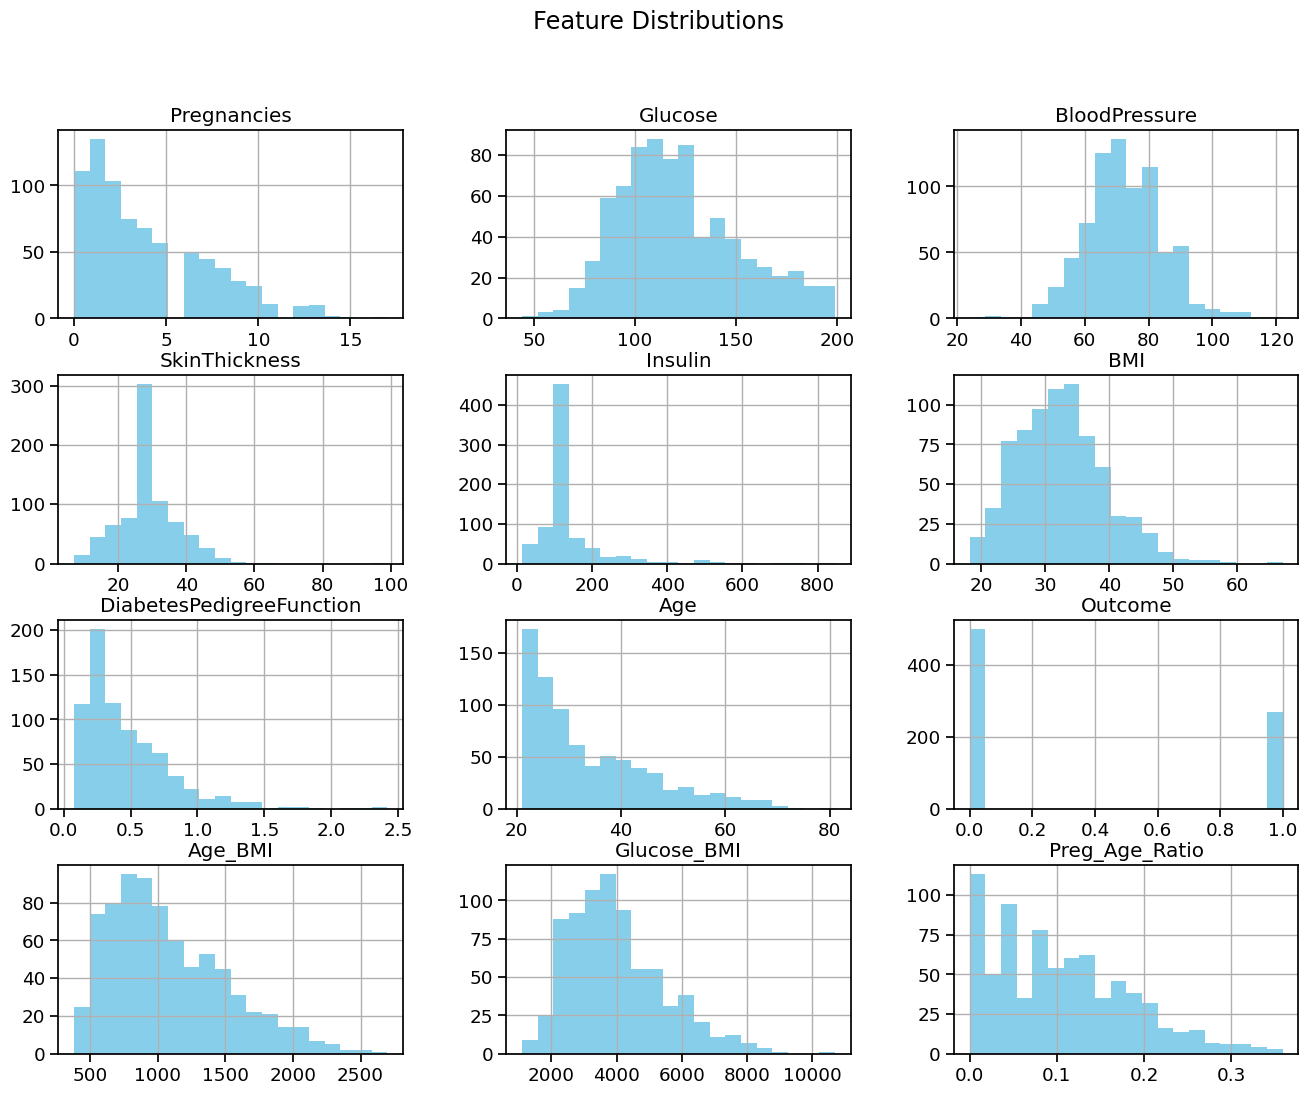

In [56]:
df_vis.hist(bins=20, figsize=(16,12), color='skyblue')
plt.suptitle('Feature Distributions')
plt.show()

### Diabetic patients tend to have higher Glucose, BMI, and Age


## Boxplots for Key Features


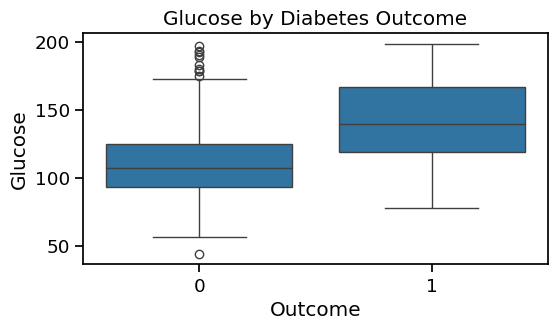

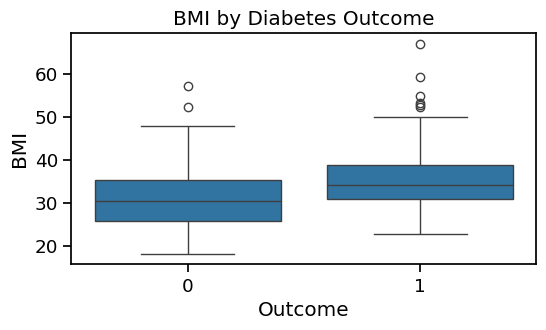

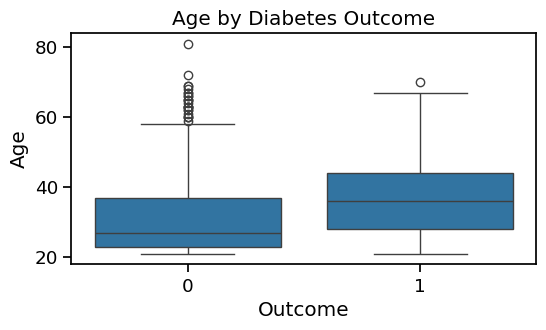

In [57]:
for col in ['Glucose','BMI','Age']:
    plt.figure(figsize=(6,3))
    sns.boxplot(x='Outcome', y=col, data=df_vis)
    plt.title(f'{col} by Diabetes Outcome')
    plt.show()

### Boxplots show median and mean Glucose, BMI, and Age are noticeably higher among diabetic patients.


## Grouped Insights

## Diabetes Rate by Age Group

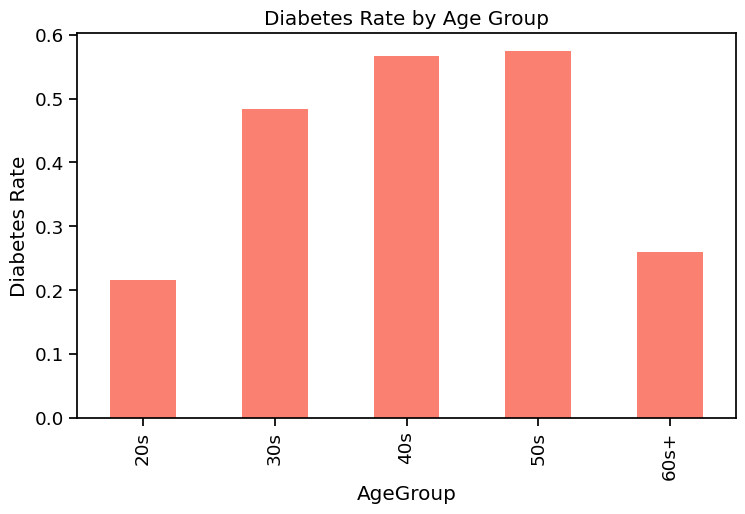

In [58]:
age_diabetes = df_vis.groupby('AgeGroup')['Outcome'].mean()
age_diabetes.plot(kind='bar', color='salmon')
plt.title('Diabetes Rate by Age Group')
plt.ylabel('Diabetes Rate')
plt.show()

### Rate increases after 40, especially with higher BMI.

## BMI Distribution by Outcome

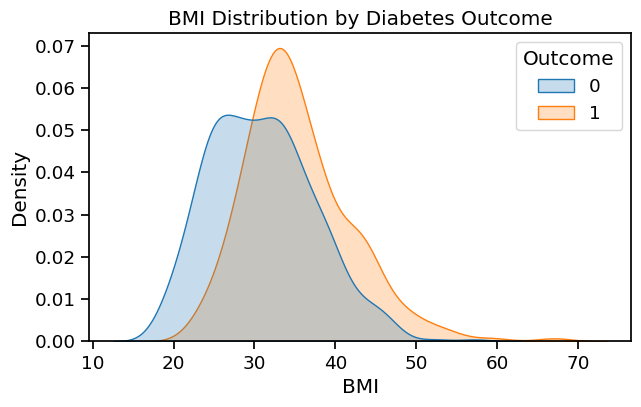

In [59]:
plt.figure(figsize=(7,4))
sns.kdeplot(data=df_vis, x="BMI", hue="Outcome", fill=True, common_norm=False)
plt.title('BMI Distribution by Diabetes Outcome')
plt.show()

### Higher BMI → higher diabetes likelihood.

# Split 


In [60]:
X = df[BASE_FEATURES].copy()
y = df['Outcome'].astype(int).copy()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=RANDOM_SEED, stratify=y_train
)

# ==== Pipeline factory ====
def make_pipeline(clf):
    return ImbPipeline(steps=[
        ('zero_nan', FunctionTransformer(zeros_to_nan, validate=False)),
        ('add_feat', FunctionTransformer(add_interactions, validate=False)),
        ('imputer',  SimpleImputer(strategy='median')),
        ('scaler',   StandardScaler()),
        ('smote',    SMOTE(random_state=RANDOM_SEED, k_neighbors=5)),
        ('clf',      clf)
    ])

models = {
    "Dummy (Most Frequent)": make_pipeline(DummyClassifier(strategy='most_frequent')),
    "Logistic Regression":   make_pipeline(LogisticRegression(max_iter=2000, solver='saga', random_state=RANDOM_SEED)),
    "Random Forest":         make_pipeline(RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=RANDOM_SEED))
}
if HAS_XGB:
    pos = int((y_tr==1).sum()); neg = int((y_tr==0).sum())
    spw = (neg / max(pos,1))
    models["XGBoost"] = make_pipeline(XGBClassifier(
        random_state=RANDOM_SEED, eval_metric='logloss', tree_method='hist',
        n_estimators=250, learning_rate=0.05, max_depth=4,
        subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0,
        scale_pos_weight=spw
    ))

# Baseline via 5-Fold OOF

In [61]:
from sklearn.compose import ColumnTransformer
num_cols = BASE_FEATURES
numeric = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())])
pre = ColumnTransformer([("num", numeric, num_cols)], remainder="drop")
base = LogisticRegression(max_iter=2000, class_weight="balanced", solver="liblinear", random_state=RANDOM_SEED)
clf = CalibratedClassifierCV(base, method="sigmoid", cv=3)
pipe_base = Pipeline([("pre", pre), ("clf", clf)])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
oof_proba = np.zeros(len(y))
for tr_idx, va_idx in skf.split(X, y):
    m = Pipeline([("pre", pre), ("clf", CalibratedClassifierCV(base, method="sigmoid", cv=3))])
    m.fit(X.iloc[tr_idx], y.iloc[tr_idx])
    oof_proba[va_idx] = m.predict_proba(X.iloc[va_idx])[:,1]

print({
    "oof_roc_auc": roc_auc_score(y, oof_proba),
    "oof_pr_auc":  average_precision_score(y, oof_proba),
    "oof_brier":   brier_score_loss(y, oof_proba)
})


{'oof_roc_auc': np.float64(0.8270223880597015), 'oof_pr_auc': np.float64(0.708159397831315), 'oof_brier': np.float64(0.15841356716283972)}


# Cross-Validation


In [62]:
def auprc_scorer(y_true , y_prob): return average_precision_score(y_true, y_prob)
def brier_scorer(y_true , y_prob): return -brier_score_loss(y_true, y_prob)

scoring = {
    'accuracy': 'accuracy',
    'precision': make_scorer(precision_score, zero_division=0),
    'recall': 'recall',
    'f1': make_scorer(f1_score, zero_division=0),
    'roc_auc': 'roc_auc',
    'auprc': make_scorer(auprc_scorer, needs_proba=True),
    'brier_neg': make_scorer(brier_scorer, needs_proba=True),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
results, best_estimators = [], {}

for name, pipe in models.items():
    scores = cross_validate(
        pipe, X_tr, y_tr, cv=cv, scoring=scoring, n_jobs=-1,
        return_estimator=True, error_score='raise'
    )
    row = {m: scores[f'test_{m}'].mean() for m in scoring}
    row.update({m+'_std': scores[f'test_{m}'].std() for m in scoring})
    row['Model'] = name
    results.append(row)
    best_idx = np.argmax(scores['test_f1'])
    best_estimators[name] = scores['estimator'][best_idx]

cv_df = pd.DataFrame(results).set_index('Model').sort_values('f1', ascending=False)
display(cv_df.round(3))
best_name = cv_df['f1'].idxmax()
best_pipe = best_estimators[best_name]
print(f"[Selected by CV (F1)]: {best_name}")


,accuracy,precision,recall,f1,roc_auc,auprc,brier_neg,accuracy_std,precision_std,recall_std,f1_std,roc_auc_std,auprc_std,brier_neg_std
Model,,,,,,,,,,,,,,
Logistic Regression,0.756,0.633,0.720,0.672,0.841,0.730,-0.167,0.041,0.053,0.085,0.056,0.038,0.058,0.026
XGBoost,0.745,0.620,0.737,0.670,0.827,0.715,-0.184,0.046,0.065,0.073,0.046,0.032,0.069,0.033
Random Forest,0.752,0.639,0.690,0.659,0.822,0.687,-0.169,0.029,0.053,0.069,0.025,0.035,0.069,0.023
Dummy (Most Frequent),0.652,0.000,0.000,0.000,0.500,0.348,-0.348,0.003,0.000,0.000,0.000,0.000,0.003,0.003


[Selected by CV (F1)]: Logistic Regression


# Single calibration (isotonic) + thresholds on VALIDATION

In [63]:
calibrated = CalibratedClassifierCV(best_pipe, method='isotonic', cv=5)
calibrated.fit(X_train, y_train)

val_proba_cal = calibrated.predict_proba(X_val)[:,1]

prec_v, rec_v, th_v = precision_recall_curve(y_val, val_proba_cal)
f1s_v = 2*(prec_v*rec_v)/(prec_v+rec_v+1e-12)
thr_f1 = th_v[np.argmax(f1s_v)] if len(th_v) else 0.5

thr_grid = np.linspace(0.05, 0.95, 37)
costs_val = [expected_cost(y_val, val_proba_cal, t, cost_fp=COST_FP, cost_fn=COST_FN) for t in thr_grid]
thr_cost = float(thr_grid[int(np.argmin(costs_val))])

print(f"Validation thresholds -> F1*:{thr_f1:.3f} | Cost*:{thr_cost:.3f} (FN cost={COST_FN})")


Validation thresholds -> F1*:0.545 | Cost*:0.175 (FN cost=7.0)


# Hyperparameter Tuning

In [64]:
param_lr = {"clf__C": np.logspace(-3, 2, 12), "clf__penalty": ["l1", "l2"]}
search_lr = RandomizedSearchCV(
    estimator=make_pipeline(LogisticRegression(max_iter=2000, solver='saga', random_state=RANDOM_SEED)),
    param_distributions=param_lr, n_iter=12, scoring="f1",
    cv=cv, n_jobs=-1, random_state=RANDOM_SEED, verbose=1
).fit(X_train, y_train)

param_rf = {
    "clf__n_estimators": [300, 500, 800],
    "clf__max_depth": [None, 4, 6, 10],
    "clf__min_samples_split": [2, 4, 6],
    "clf__min_samples_leaf": [1, 2, 3],
    "clf__max_features": ["sqrt", "log2", None],
}
search_rf = RandomizedSearchCV(
    estimator=make_pipeline(RandomForestClassifier(n_jobs=-1, random_state=RANDOM_SEED)),
    param_distributions=param_rf, n_iter=25, scoring="f1",
    cv=cv, n_jobs=-1, random_state=RANDOM_SEED, verbose=1
).fit(X_train, y_train)

if search_lr.best_score_ >= search_rf.best_score_:
    final_pipe = search_lr.best_estimator_
    final_name = "Logistic Regression (tuned)"
else:
    final_pipe = search_rf.best_estimator_
    final_name = "Random Forest (tuned)"

# Re-calibrate once on (X_train, y_train)
final_calibrated = CalibratedClassifierCV(final_pipe, method='isotonic', cv=5)
final_calibrated.fit(X_train, y_train)

# Pick operating threshold on VALIDATION for the final model
val_proba_cal_final = final_calibrated.predict_proba(X_val)[:, 1]
thr_grid = np.linspace(0.05, 0.95, 37)
costs_val_final = [expected_cost(y_val, val_proba_cal_final, t, cost_fp=COST_FP, cost_fn=COST_FN) for t in thr_grid]
oper_thr_final = float(thr_grid[int(np.argmin(costs_val_final))])
print(f"[{final_name}] operating threshold (cost-based) = {oper_thr_final:.3f}")


Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 25 candidates, totalling 125 fits
[Random Forest (tuned)] operating threshold (cost-based) = 0.200


# Final Evaluation on TEST (calibrated + operating threshold) 


== Final Tuned @0.50 (calibrated prob) ==
Threshold : 0.5
Accuracy  : 0.7142857142857143
Precision : 0.6041666666666666
Recall    : 0.5370370370370371
F1        : 0.5686274509803921
ROC-AUC   : 0.8132407407407407
AUPRC     : 0.6944413033264842
Brier     : 0.1687882946070063

Classification Report:
               precision    recall  f1-score   support

           0      0.764     0.810     0.786       100
           1      0.604     0.537     0.569        54

    accuracy                          0.714       154
   macro avg      0.684     0.674     0.678       154
weighted avg      0.708     0.714     0.710       154



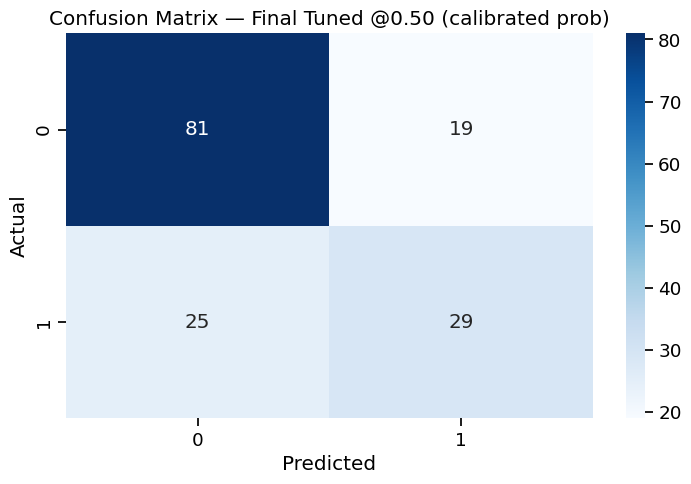


== Final Tuned @oper_thr=0.20 (calibrated prob) ==
Threshold : 0.2
Accuracy  : 0.7207792207792207
Precision : 0.5647058823529412
Recall    : 0.8888888888888888
F1        : 0.6906474820143885
ROC-AUC   : 0.8132407407407407
AUPRC     : 0.6944413033264842
Brier     : 0.1687882946070063

Classification Report:
               precision    recall  f1-score   support

           0      0.913     0.630     0.746       100
           1      0.565     0.889     0.691        54

    accuracy                          0.721       154
   macro avg      0.739     0.759     0.718       154
weighted avg      0.791     0.721     0.726       154



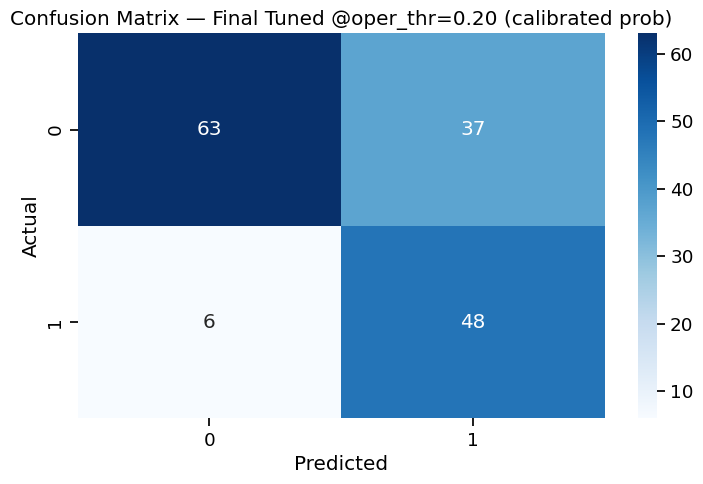

In [65]:
def report_block(title, y_true, y_prob, thr):
    y_pred = (y_prob >= thr).astype(int)
    print(f"\n== {title} ==")
    print("Threshold :", thr)
    print("Accuracy  :", accuracy_score(y_true, y_pred))
    print("Precision :", precision_score(y_true, y_pred, zero_division=0))
    print("Recall    :", recall_score(y_true, y_pred))
    print("F1        :", f1_score(y_true, y_pred))
    print("ROC-AUC   :", roc_auc_score(y_true, y_prob))
    print("AUPRC     :", average_precision_score(y_true, y_prob))
    print("Brier     :", brier_score_loss(y_true, y_prob))
    print("\nClassification Report:\n", classification_report(y_true, y_pred, digits=3, zero_division=0))
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix — {title}')
    plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.show()

test_proba_cal_final = final_calibrated.predict_proba(X_test)[:, 1]
report_block("Final Tuned @0.50 (calibrated prob)", y_test, test_proba_cal_final, 0.50)
report_block(f"Final Tuned @oper_thr={oper_thr_final:.2f} (calibrated prob)", y_test, test_proba_cal_final, oper_thr_final)


# Reliability diagram on TEST (calibrated)


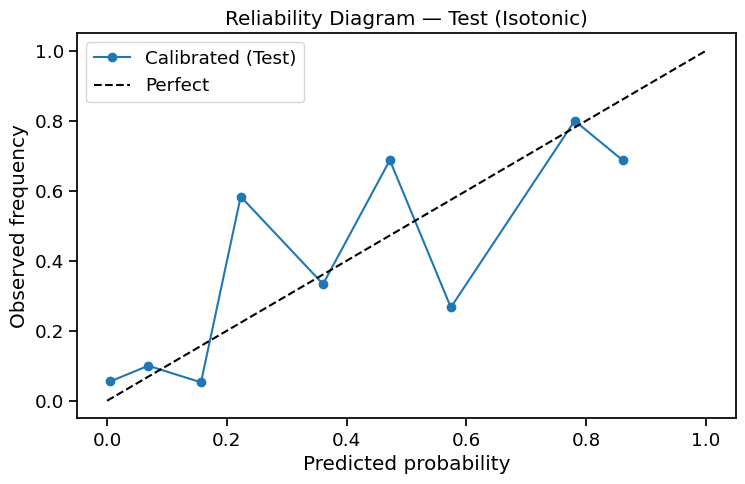

In [66]:
prob_true, prob_pred = calibration_curve(y_test, test_proba_cal_final, n_bins=10, strategy='quantile')
plt.figure()
plt.plot(prob_pred, prob_true, marker='o', label='Calibrated (Test)')
plt.plot([0,1], [0,1], 'k--', label='Perfect')
plt.xlabel('Predicted probability')
plt.ylabel('Observed frequency')
plt.title('Reliability Diagram — Test (Isotonic)')
plt.legend()
plt.show()

# Model Comparison (PR & ROC) on Test


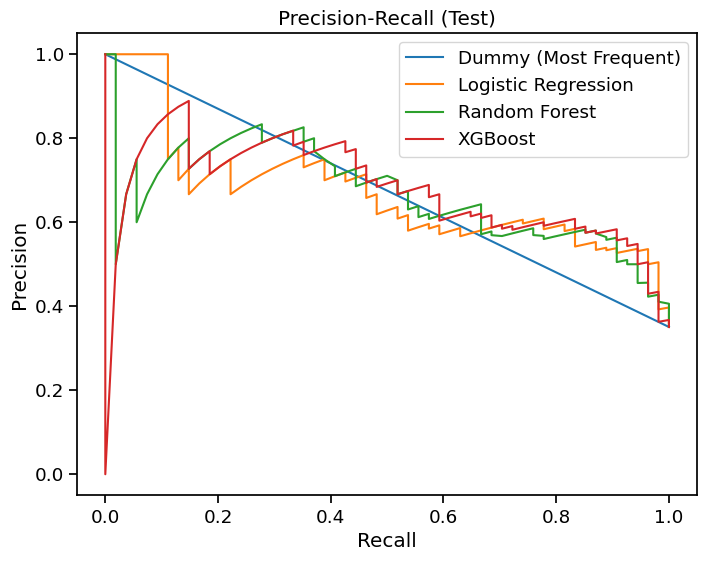

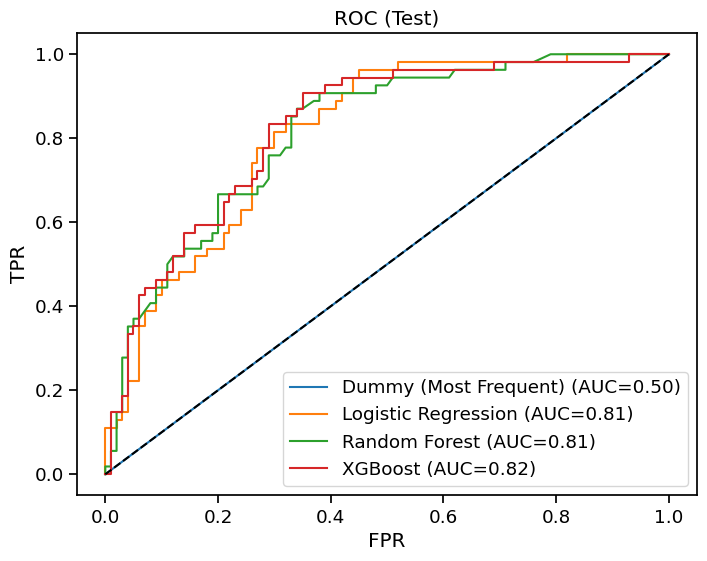

In [67]:
y_probas = {}
for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    y_probas[name] = pipe.predict_proba(X_test)[:,1]

plt.figure(figsize=(8,6))
for name, proba in y_probas.items():
    p, r, _ = precision_recall_curve(y_test, proba)
    plt.plot(r, p, label=name)
plt.xlabel('Recall'); plt.ylabel('Precision'); plt.title('Precision-Recall (Test)'); plt.legend(); plt.show()

plt.figure(figsize=(8,6))
for name, proba in y_probas.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc(fpr,tpr):.2f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('ROC (Test)'); plt.legend(); plt.show()


# Permutation Importance

In [68]:
r = permutation_importance(
    final_calibrated, X_test, y_test, n_repeats=10,
    random_state=RANDOM_SEED, n_jobs=-1, scoring='average_precision'
)
pi = pd.Series(r.importances_mean, index=X_test.columns).sort_values(ascending=False)

fig = px.bar(pi.head(12), title="Permutation Importance (Top 12)",
             labels={'value':'Mean Importance','index':'Feature'})
fig.update_layout(width=800, height=420)
fig.show()
print("\nTop features:\n", pi.head(10).round(4))



Top features:
 Glucose                     0.1402
BMI                         0.0740
Age                         0.0501
DiabetesPedigreeFunction    0.0214
Insulin                     0.0140
BloodPressure               0.0045
Pregnancies                -0.0017
SkinThickness              -0.0026
dtype: float64


# Learning Curve


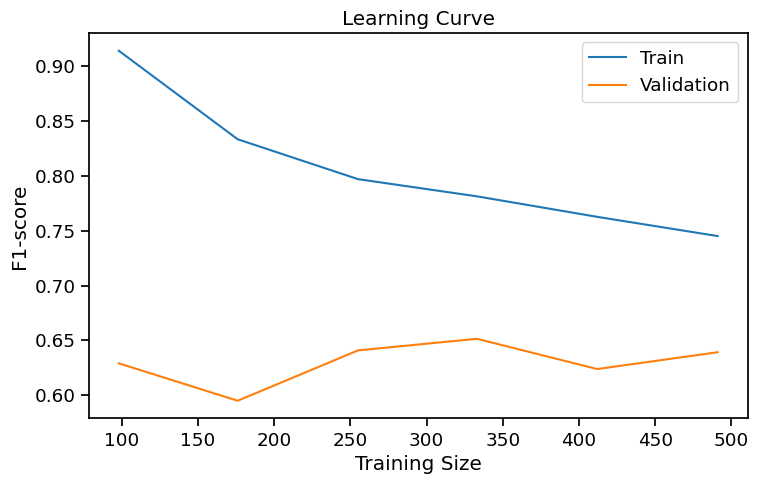

In [69]:
train_sizes, train_scores, val_scores = learning_curve(
    final_calibrated, X_train, y_train, cv=5, scoring='f1', n_jobs=-1,
    train_sizes=np.linspace(0.2, 1.0, 6), shuffle=True, random_state=RANDOM_SEED
)
plt.figure()
plt.plot(train_sizes, train_scores.mean(axis=1), label='Train')
plt.plot(train_sizes, val_scores.mean(axis=1), label='Validation')
plt.xlabel('Training Size'); plt.ylabel('F1-score')
plt.title('Learning Curve'); plt.legend(); plt.show()



# SAVE ARTIFACTS

In [71]:
SAVE_ARTIFACTS = True
ARTIFACTS_DIR = Path('./artifacts'); ARTIFACTS_DIR.mkdir(exist_ok=True)

bundle = {
    'pipeline': final_calibrated,
    'features': BASE_FEATURES,
    'cv_summary': cv_df.round(4).to_dict(),
    'best_model_name': final_name,
    'calibration': 'isotonic',
    'operating_threshold': float(oper_thr_final),
    'cost_fp': float(COST_FP),
    'cost_fn': float(COST_FN),
    'random_seed': int(RANDOM_SEED),
    'notes': 'Pima diabetes — tuned + calibrated; threshold chosen on validation by cost curve.'
}
if SAVE_ARTIFACTS:
    joblib.dump(bundle, ARTIFACTS_DIR / 'pima_best_pipeline.joblib')
    print(f"Saved → artifacts/pima_best_pipeline.joblib | oper_thr={oper_thr_final:.3f}")


Saved → artifacts/pima_best_pipeline.joblib | oper_thr=0.200


In [72]:
print("""
Key Insights
------------
• Final model: {} (isotonic-calibrated).
• Operating threshold chosen by cost curve (FP={} , FN={}), tuned on validation only.
• Top drivers by permutation importance typically: Glucose, BMI, Age, Pregnancies.
• Report both @0.50 and @oper_thr to show trade-off (recall ↑ vs precision ↓).
""".format(final_name, COST_FP, COST_FN))



Key Insights
------------
• Final model: Random Forest (tuned) (isotonic-calibrated).
• Operating threshold chosen by cost curve (FP=1.0 , FN=7.0), tuned on validation only.
• Top drivers by permutation importance typically: Glucose, BMI, Age, Pregnancies.
• Report both @0.50 and @oper_thr to show trade-off (recall ↑ vs precision ↓).

